# 💄 Sephora Ürün Öneri Sistemi

**Tek notebook — baştan sona çalıştırılabilir**

```
review_text_features.parquet          review_concern_level.parquet
         │                                       │
         └──────────────┬────────────────────────┘
                        │
               Aggregate Scoring
               Feature Engineering
               Feature Seçimi
                        │
          ┌─────────────┼─────────────┐
    Katman 1        Katman 2       Katman 3
    Aggregate       ML Ranking     Semantic
    Baseline        (LightGBM /    (SBERT)
                     XGBoost /
                     CatBoost)
          └─────────────┼─────────────┘
                 Ensemble Score
               Top-5 Öneri Listesi
```

| Bölüm | İçerik |
|-------|--------|
| 0 | Kurulum & Konfigürasyon |
| 1 | Veri Yükleme & EDA |
| 2 | Aggregate Scoring (Katman 1) |
| 3 | Feature Engineering |
| 4 | Feature Seçimi |
| 5 | CV Framework |
| 6 | Baseline Model Karşılaştırması |
| 7 | Optuna Hyperparameter Tuning |
| 8 | Final Model Eğitimi & SHAP |
| 9 | Semantic Retrieval (Katman 3) |
| 10 | Ensemble Ağırlık Optimizasyonu |
| 11 | Hata Analizi |
| 12 | Öneri Motoru & Demo |
| 13 | Model Kaydetme & Özet Rapor |

## 0. Kurulum & Konfigürasyon

In [4]:
# !pip install lightgbm xgboost catboost optuna sentence-transformers scikit-learn pandas numpy matplotlib seaborn shap

import warnings, json, pickle, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional

# ── ML ───────────────────────────────────────────────────────────────────────
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRanker, Pool
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import ndcg_score
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE
from sklearn.feature_selection import VarianceThreshold

# ── Semantic ─────────────────────────────────────────────────────────────────
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# ── Hyperparameter tuning ────────────────────────────────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Görsel ───────────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']

# ── Seed ─────────────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ══════════════════════════════════════════════════════════════════════════════
#  ▶  BURAYA KENDİ YOLLARINIZI GİRİN
# ══════════════════════════════════════════════════════════════════════════════
DATA_DIR   = Path('../data/processed')   # parquet dosyalarının bulunduğu klasör
OUTPUT_DIR = Path('outputs')
MODEL_DIR  = OUTPUT_DIR / 'models'
METRICS_DIR= OUTPUT_DIR / 'metrics'
TUNING_DIR = OUTPUT_DIR / 'metrics' / 'tuning'
# ══════════════════════════════════════════════════════════════════════════════

for d in [MODEL_DIR, METRICS_DIR, TUNING_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SBERT_MODEL_NAME = 'all-MiniLM-L6-v2'   # daha iyi kalite: 'all-mpnet-base-v2'
N_TRIALS = 50                            # Optuna trial sayısı (artırılabilir)
N_SPLITS = 5                             # CV fold sayısı
MIN_REVIEWS = 3                          # öneri için minimum review filtresi

print('✅ Kütüphaneler yüklendi.')
print(f'   Modeller   → {MODEL_DIR}')
print(f'   Metrikler  → {METRICS_DIR}')
print(f'   Tuning     → {TUNING_DIR}')

✅ Kütüphaneler yüklendi.
   Modeller   → outputs/models
   Metrikler  → outputs/metrics
   Tuning     → outputs/metrics/tuning


## 1. Veri Yükleme & EDA

In [5]:
rtf = pd.read_parquet(DATA_DIR / 'review_text_features.parquet')
rcl = pd.read_parquet(DATA_DIR / 'review_concern_level.parquet')

print(f'review_text_features : {rtf.shape}')
print(f'review_concern_level : {rcl.shape}')
print()
print('review_text_features sütunları:')
print(rtf.dtypes)
print()
print('review_concern_level sütunları:')
print(rcl.dtypes)

review_text_features : (1092743, 22)
review_concern_level : (2832857, 22)

review_text_features sütunları:
author_id              string[python]
product_id                     object
product_name_final             object
brand_name_final               object
rating                          int64
rating_category                object
is_recommended                float64
skin_type                      object
primary_category               object
secondary_category             object
review_title                   object
review_text                    object
raw_text                       object
normalized_text                object
clean_text                     object
review_text_length              int64
raw_text_length                 int64
has_title                       int64
rule_based_concerns            object
semantic_concerns              object
final_concerns                 object
concern_count                   int64
dtype: object

review_concern_level sütunları:
row_index 

In [6]:
print('=== CONCERN DAĞILIMI ===')
print(rcl['concern'].value_counts())
print()
print('=== EFFECT LABEL DAĞILIMI ===')
print(rcl['effect_label'].value_counts())
print()
print('=== SKIN TYPE DAĞILIMI ===')
if 'skin_type' in rtf.columns:
    print(rtf['skin_type'].value_counts())
print()
print('=== UNIQUE ÜRÜN SAYISI ===')
print(f"review_text_features: {rtf['product_id'].nunique()} ürün")
print(f"review_concern_level: {rcl['product_id'].nunique()} ürün")

=== CONCERN DAĞILIMI ===
concern
oiliness       721683
dryness        411244
dullness       335381
acne           334338
texture        256488
sensitivity    243182
redness        202932
dark_spots     130679
aging          129925
pores           67005
Name: count, dtype: int64

=== EFFECT LABEL DAĞILIMI ===
effect_label
unknown        2349125
target_only     219887
helped          191843
worsened         72002
Name: count, dtype: int64

=== SKIN TYPE DAĞILIMI ===
skin_type
combination    543712
dry            185651
normal         131674
oily           120296
Name: count, dtype: int64

=== UNIQUE ÜRÜN SAYISI ===
review_text_features: 2351 ürün
review_concern_level: 2327 ürün


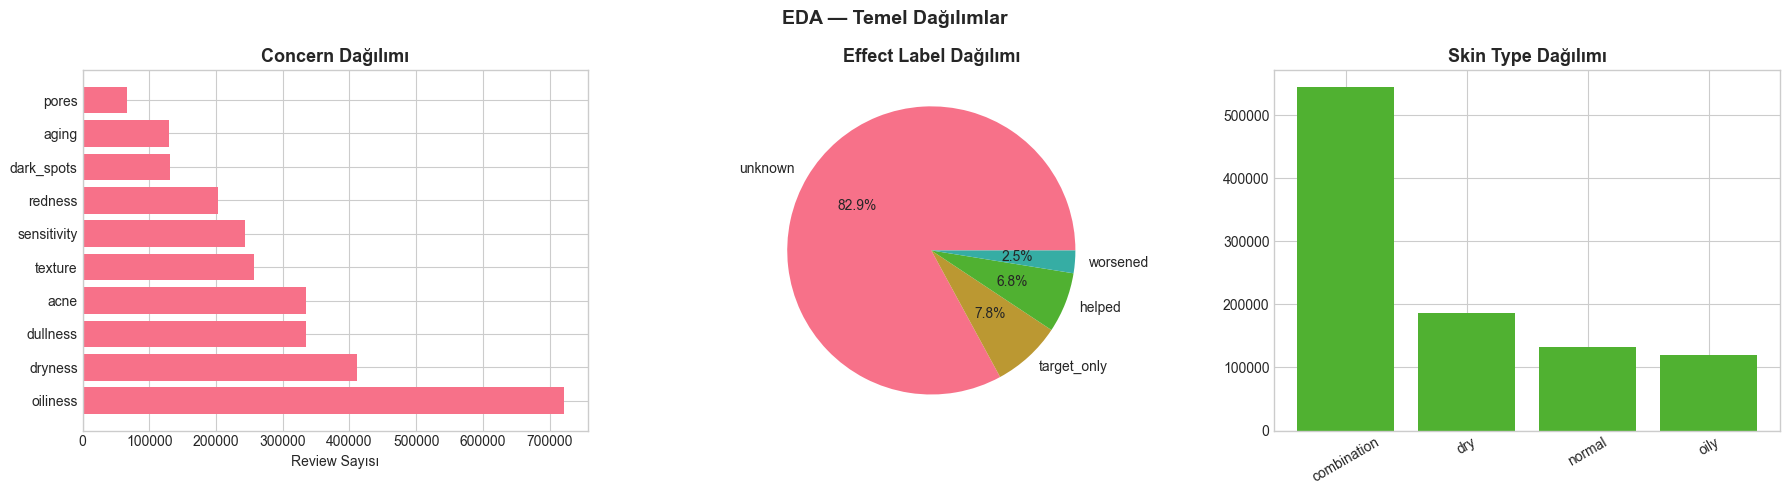

📊 EDA grafiği kaydedildi.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Concern dağılımı
concern_counts = rcl['concern'].value_counts()
axes[0].barh(concern_counts.index, concern_counts.values, color=COLORS[0])
axes[0].set_title('Concern Dağılımı', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Review Sayısı')

# Effect label dağılımı
effect_counts = rcl['effect_label'].value_counts()
axes[1].pie(effect_counts.values, labels=effect_counts.index,
            autopct='%1.1f%%', colors=COLORS[:len(effect_counts)])
axes[1].set_title('Effect Label Dağılımı', fontsize=13, fontweight='bold')

# Skin type dağılımı
if 'skin_type' in rtf.columns:
    skin_counts = rtf['skin_type'].value_counts().head(8)
    axes[2].bar(skin_counts.index, skin_counts.values, color=COLORS[2])
    axes[2].set_title('Skin Type Dağılımı', fontsize=13, fontweight='bold')
    axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('EDA — Temel Dağılımlar', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(METRICS_DIR / 'eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 EDA grafiği kaydedildi.')

## 2. Aggregate Scoring — Katman 1

Her `(product_id, concern, skin_type)` üçlüsü için deterministik skor:

```
effect_weight  = +1.0  (helped)
               = -1.5  (worsened)   ← negatif deneyim daha ağır basar
               = +0.3  (target_only)
               =  0.0  (unknown)

weighted_score = rating_norm × effect_weight × concern_confidence
aggregate_score = mean(weighted_score) + log1p(review_count) / 10
```

In [8]:
EFFECT_WEIGHTS = {
    'helped': 1.0,
    'worsened': -1.5,
    'target_only': 0.3,
    'unknown': 0.0,
}


def build_aggregate_scores(rcl: pd.DataFrame, rtf: pd.DataFrame) -> pd.DataFrame:
    """
    (product_id, concern, skin_type) bazında aggregate skor üretir.
    """
    df = rcl.copy()

    # skin_type yok ise review_text_features'dan al
    if 'skin_type' not in df.columns or df['skin_type'].isna().all():
        skin_map = rtf.set_index(['author_id', 'product_id'])['skin_type'].to_dict()
        df['skin_type'] = df.apply(
            lambda r: skin_map.get((r.get('author_id'), r['product_id']), 'Unknown'), axis=1
        )
    df['skin_type'] = df['skin_type'].fillna('Unknown')

    df['effect_weight'] = df['effect_label'].map(EFFECT_WEIGHTS).fillna(0.0)
    df['rating']        = pd.to_numeric(df['rating'], errors='coerce').fillna(3.0)
    df['rating_norm']   = (df['rating'] - 1) / 4
    df['weighted_score'] = df['rating_norm'] * df['effect_weight'] * df['concern_confidence']

    agg = df.groupby(['product_id', 'concern', 'skin_type']).agg(
        product_name       = ('product_name_final', 'first'),
        brand_name         = ('brand_name_final',   'first'),
        primary_category   = ('primary_category',   'first'),
        secondary_category = ('secondary_category', 'first'),
        mean_weighted_score= ('weighted_score',      'mean'),
        mean_rating        = ('rating',              'mean'),
        review_count       = ('product_id',          'count'),
        helped_count       = ('effect_label', lambda x: (x == 'helped').sum()),
        worsened_count     = ('effect_label', lambda x: (x == 'worsened').sum()),
        mean_confidence    = ('concern_confidence',  'mean'),
    ).reset_index()

    agg['review_count_bonus'] = np.log1p(agg['review_count']) / 10
    agg['helped_ratio']       = agg['helped_count']  / agg['review_count'].clip(lower=1)
    agg['worsened_ratio']     = agg['worsened_count'] / agg['review_count'].clip(lower=1)
    agg['aggregate_score']    = agg['mean_weighted_score'] + agg['review_count_bonus']

    return agg.sort_values('aggregate_score', ascending=False)


agg_scores = build_aggregate_scores(rcl, rtf)
print(f'Aggregate score tablosu: {agg_scores.shape}')
agg_scores.head(8)

Aggregate score tablosu: (81019, 17)


,product_id,concern,skin_type,product_name,brand_name,primary_category,secondary_category,mean_weighted_score,mean_rating,review_count,helped_count,worsened_count,mean_confidence,review_count_bonus,helped_ratio,worsened_ratio,aggregate_score
75225,P503197,dullness,oily,Juneberry & Collagen Hydrating Cold Cream Clea...,alpyn beauty,Skincare,Cleansers,1.0,5.0,4,4,0,1.0,0.160944,1.0,0.0,1.160944
52950,P471000,aging,dry,Algae Niacinamide Moisture Veil,Algenist,Skincare,Moisturizers,1.0,5.0,4,4,0,1.0,0.160944,1.0,0.0,1.160944
54430,P472021,aging,normal,Mochi Mochi Luminous Plumping & Hydrating Mois...,DAMDAM,Skincare,Moisturizers,1.0,5.0,4,4,0,1.0,0.160944,1.0,0.0,1.160944
71884,P500746,aging,dry,Hydrating Serum with Hyaluronic Acid,First Aid Beauty,Skincare,Treatments,1.0,5.0,3,3,0,1.0,0.138629,1.0,0.0,1.138629
52850,P470535,pores,normal,KateCeuticals Resurfacing Overnight Peel with ...,Kate Somerville,Skincare,Treatments,1.0,5.0,3,3,0,1.0,0.138629,1.0,0.0,1.138629
65286,P481341,aging,dry,Alpha Beta Daily Moisturizer,Dr. Dennis Gross Skincare,Skincare,Moisturizers,1.0,5.0,3,3,0,1.0,0.138629,1.0,0.0,1.138629
79873,P505133,pores,combination,High Performance Face Cleanser for Clear Skin ...,MACRENE actives,Skincare,Cleansers,1.0,5.0,2,2,0,1.0,0.109861,1.0,0.0,1.109861
28844,P442838,aging,Unknown,Barrier+ Triple Lipid-Boost 360° Brightening E...,Skinfix,Skincare,Eye Care,1.0,5.0,2,2,0,1.0,0.109861,1.0,0.0,1.109861


In [9]:
# Hızlı baseline öneri (Katman 1 tek başına)
def recommend_baseline(concern: str, skin_type: str, top_n: int = 5) -> pd.DataFrame:
    concern   = concern.lower().strip()
    mask      = agg_scores['concern'] == concern
    skin_mask = agg_scores['skin_type'].str.lower() == skin_type.lower()
    if skin_mask[mask].sum() > 0:
        mask = mask & skin_mask
    return (
        agg_scores[mask]
        .sort_values('aggregate_score', ascending=False)
        .head(top_n)
        [['product_id','product_name','brand_name','aggregate_score',
          'mean_rating','review_count','helped_ratio','worsened_ratio']]
    )

print('=== Baseline Öneri Testi ===')
recommend_baseline('acne', 'oily', top_n=5)

=== Baseline Öneri Testi ===


,product_id,product_name,brand_name,aggregate_score,mean_rating,review_count,helped_ratio,worsened_ratio
69865,P484055,Water Bank Blue Hyaluronic Hydration Set,LANEIGE,1.069315,5.0,1,1.0,0.0
59161,P475195,Protect + Plump Firming & Hydrating Face Moist...,TULA Skincare,1.069315,5.0,1,1.0,0.0
61488,P478020,Lemon-Aid Makeup-Removing Cleansing Gel,Naturally Serious,1.069315,5.0,1,1.0,0.0
55354,P472471,Acne Remedy Overnight Repair Moisturizer,Jack Black,1.069315,5.0,1,1.0,0.0
14269,P416728,Dreamskin Skin Perfector Refill,Dior,1.069315,5.0,1,1.0,0.0


## 3. Feature Engineering

In [10]:
def build_ml_features(agg_scores: pd.DataFrame) -> Tuple[pd.DataFrame, Dict]:
    """
    LightGBM / XGBoost / CatBoost için genişletilmiş feature matrix üretir.

    Relevance Label (0-3):
        0 = worsened_ratio > 0.30 veya helped_ratio < 0.10
        1 = orta (helped 0.10–0.35)
        2 = iyi  (helped 0.35–0.60)
        3 = çok iyi (helped ≥ 0.60 ve mean_rating ≥ 3.5)
    """
    df = agg_scores.copy()

    # ── Relevance Label ──────────────────────────────────────────────────────
    conditions = [
        (df['worsened_ratio'] > 0.30) | (df['helped_ratio'] < 0.10),
        (df['helped_ratio'] >= 0.10) & (df['helped_ratio'] < 0.35),
        (df['helped_ratio'] >= 0.35) & (df['helped_ratio'] < 0.60),
        (df['helped_ratio'] >= 0.60) & (df['mean_rating'] >= 3.5),
    ]
    df['relevance_label'] = np.select(conditions, [0, 1, 2, 3], default=1)

    # ── Temel Feature'lar ────────────────────────────────────────────────────
    df['log_review_count']    = np.log1p(df['review_count'])
    df['review_count_sqrt']   = np.sqrt(df['review_count'])
    df['rating_x_helped']     = df['mean_rating']  * df['helped_ratio']
    df['net_effect_ratio']    = df['helped_ratio']  - df['worsened_ratio']
    df['confidence_x_score']  = df['mean_confidence'] * df['mean_weighted_score']
    df['helped_x_confidence'] = df['helped_ratio']    * df['mean_confidence']

    # ── Interaction Feature'lar ──────────────────────────────────────────────
    df['rating_x_net_effect']  = df['mean_rating']         * df['net_effect_ratio']
    df['score_x_log_reviews']  = df['mean_weighted_score'] * df['log_review_count']
    df['helped_sq']            = df['helped_ratio'] ** 2
    df['worsened_sq']          = df['worsened_ratio'] ** 2
    df['confidence_sq']        = df['mean_confidence'] ** 2

    # ── Categorical Encode ───────────────────────────────────────────────────
    le_concern = LabelEncoder()
    le_skin    = LabelEncoder()
    le_pcat    = LabelEncoder()
    le_scat    = LabelEncoder()

    df['concern_enc']   = le_concern.fit_transform(df['concern'].astype(str))
    df['skin_type_enc'] = le_skin.fit_transform(df['skin_type'].astype(str))
    df['pcat_enc']      = le_pcat.fit_transform(df['primary_category'].fillna('Unknown').astype(str))
    df['scat_enc']      = le_scat.fit_transform(df['secondary_category'].fillna('Unknown').astype(str))

    # Query ID (concern × skin_type kombinasyonu)
    df['query_id']     = df['concern_enc'].astype(str) + '_' + df['skin_type_enc'].astype(str)
    qle                = LabelEncoder()
    df['query_id_enc'] = qle.fit_transform(df['query_id'])

    encoders = {
        'concern': le_concern, 'skin_type': le_skin,
        'pcat': le_pcat, 'scat': le_scat, 'query': qle
    }
    return df, encoders


ml_df, encoders = build_ml_features(agg_scores)

# ── Feature grupları ─────────────────────────────────────────────────────────
FEATURE_COLS_BASE = [
    'mean_weighted_score', 'mean_rating', 'log_review_count',
    'helped_ratio', 'worsened_ratio', 'net_effect_ratio',
    'mean_confidence', 'review_count_bonus',
    'rating_x_helped', 'confidence_x_score',
    'concern_enc', 'skin_type_enc',
]

FEATURE_COLS_EXTENDED = FEATURE_COLS_BASE + [
    'helped_x_confidence', 'rating_x_net_effect', 'score_x_log_reviews',
    'helped_sq', 'worsened_sq', 'confidence_sq', 'review_count_sqrt',
    'pcat_enc', 'scat_enc',
]

CAT_FEATURES     = ['concern_enc', 'skin_type_enc', 'pcat_enc', 'scat_enc']
cat_feature_idxs = [FEATURE_COLS_EXTENDED.index(f) for f in CAT_FEATURES if f in FEATURE_COLS_EXTENDED]

print(f'Base feature sayısı    : {len(FEATURE_COLS_BASE)}')
print(f'Extended feature sayısı: {len(FEATURE_COLS_EXTENDED)}')
print(f'ML df boyutu           : {ml_df.shape}')
print(f'\nRelevance label dağılımı:')
print(ml_df['relevance_label'].value_counts().sort_index())

Base feature sayısı    : 12
Extended feature sayısı: 21
ML df boyutu           : (81019, 35)

Relevance label dağılımı:
relevance_label
0    61575
1    15873
2     2219
3     1352
Name: count, dtype: int64


## 4. Feature Seçimi

Düşük varyans (elenen): ['pcat_enc']


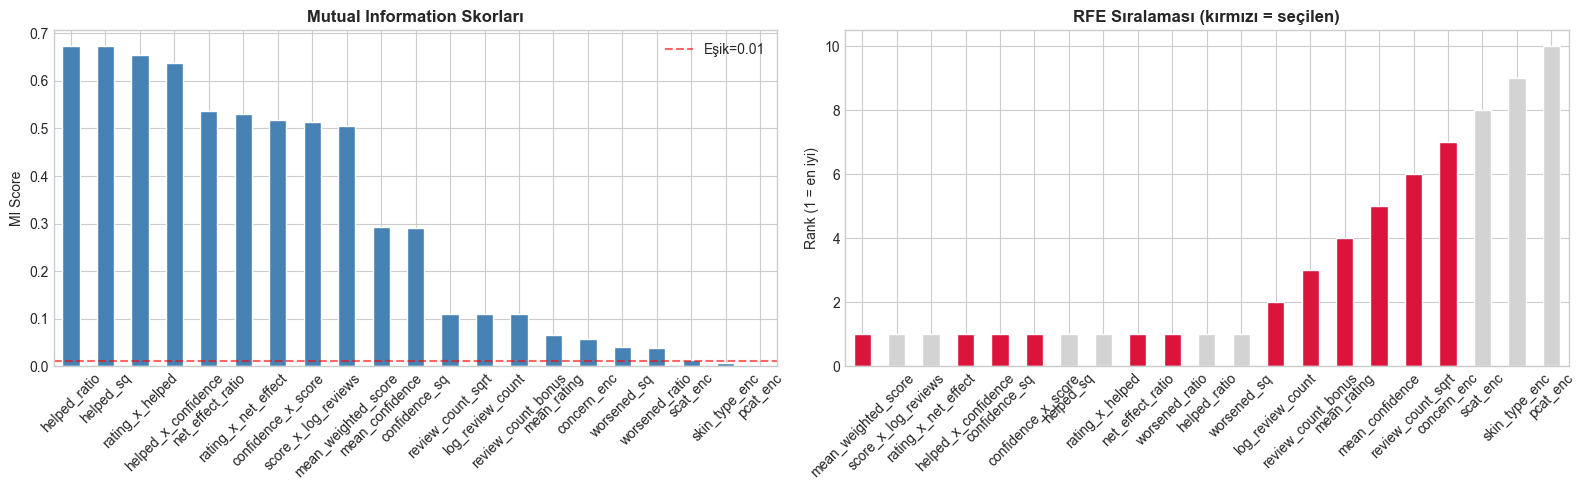


MI seçilen (20): ['helped_ratio', 'helped_sq', 'rating_x_helped', 'helped_x_confidence', 'net_effect_ratio', 'rating_x_net_effect', 'confidence_x_score', 'score_x_log_reviews', 'mean_weighted_score', 'mean_confidence', 'confidence_sq', 'review_count_sqrt', 'log_review_count', 'review_count_bonus', 'mean_rating', 'concern_enc', 'worsened_sq', 'worsened_ratio', 'scat_enc', 'skin_type_enc']
RFE seçilen (12): ['mean_weighted_score', 'helped_ratio', 'worsened_ratio', 'net_effect_ratio', 'rating_x_helped', 'confidence_x_score', 'helped_x_confidence', 'rating_x_net_effect', 'score_x_log_reviews', 'helped_sq', 'worsened_sq', 'confidence_sq']

Final SELECTED_FEATURES (21): ['mean_weighted_score', 'mean_rating', 'log_review_count', 'helped_ratio', 'worsened_ratio', 'net_effect_ratio', 'mean_confidence', 'review_count_bonus', 'rating_x_helped', 'confidence_x_score', 'concern_enc', 'skin_type_enc', 'helped_x_confidence', 'rating_x_net_effect', 'score_x_log_reviews', 'helped_sq', 'worsened_sq', 'c

In [11]:
# ── 4.1 Varyans Filtresi ─────────────────────────────────────────────────────
X_all = ml_df[FEATURE_COLS_EXTENDED].fillna(0)
y_all = ml_df['relevance_label']

vt = VarianceThreshold(threshold=0.001)
vt.fit(X_all)
low_var = [f for f, s in zip(FEATURE_COLS_EXTENDED, vt.get_support()) if not s]
print(f'Düşük varyans (elenen): {low_var}')

# ── 4.2 Mutual Information Skorları ─────────────────────────────────────────
mi_selector = SelectKBest(score_func=mutual_info_classif, k='all')
mi_selector.fit(X_all, y_all)

mi_df = pd.Series(mi_selector.scores_, index=FEATURE_COLS_EXTENDED).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

mi_df.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Mutual Information Skorları', fontsize=12, fontweight='bold')
axes[0].set_ylabel('MI Score')
axes[0].axhline(0.01, color='red', ls='--', alpha=0.6, label='Eşik=0.01')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# ── 4.3 RFE (Random Forest tabanlı) ─────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
rfe_model = RandomForestClassifier(n_estimators=50, random_state=SEED, n_jobs=-1)
rfe = RFE(estimator=rfe_model, n_features_to_select=min(12, len(FEATURE_COLS_EXTENDED)), step=1)
rfe.fit(X_all, y_all)

rfe_rank = pd.Series(rfe.ranking_, index=FEATURE_COLS_EXTENDED).sort_values()
colors_rfe = ['crimson' if s else 'lightgray' for s in rfe.support_]
rfe_rank.plot(kind='bar', ax=axes[1], color=colors_rfe, edgecolor='white')
axes[1].set_title('RFE Sıralaması (kırmızı = seçilen)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Rank (1 = en iyi)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(METRICS_DIR / 'feature_selection.png', dpi=150, bbox_inches='tight')
plt.show()

# Seçilen feature setini belirle
MI_THRESHOLD = 0.005
selected_mi  = mi_df[mi_df >= MI_THRESHOLD].index.tolist()
selected_rfe = [f for f, s in zip(FEATURE_COLS_EXTENDED, rfe.support_) if s]

# İkisinin kesişimi + tüm kategorik feature'lar (bunları her zaman tut)
SELECTED_FEATURES = list(set(selected_mi) | set(selected_rfe) | set(CAT_FEATURES))
SELECTED_FEATURES = [f for f in FEATURE_COLS_EXTENDED if f in SELECTED_FEATURES]  # sırayı koru

print(f'\nMI seçilen ({len(selected_mi)}): {selected_mi}')
print(f'RFE seçilen ({len(selected_rfe)}): {selected_rfe}')
print(f'\nFinal SELECTED_FEATURES ({len(SELECTED_FEATURES)}): {SELECTED_FEATURES}')

# Feature selection sonuçlarını kaydet
feat_sel_summary = {
    'mi_scores':        mi_df.round(4).to_dict(),
    'rfe_selected':     selected_rfe,
    'mi_selected':      selected_mi,
    'final_selected':   SELECTED_FEATURES,
    'low_variance_dropped': low_var,
}
with open(METRICS_DIR / 'feature_selection.json', 'w') as f:
    json.dump(feat_sel_summary, f, indent=2)
print('\n💾 Feature seçimi sonuçları kaydedildi.')

## 5. Cross-Validation Framework

**Strateji:** Group-based K-Fold — `query_id` (concern × skin_type) grupları bölünmeden ayrılır → data leakage yok.

In [12]:
@dataclass
class CVResult:
    model_name:    str
    ndcg5_scores:  List[float] = field(default_factory=list)
    ndcg10_scores: List[float] = field(default_factory=list)
    train_times:   List[float] = field(default_factory=list)

    @property
    def mean_ndcg5(self):       return np.mean(self.ndcg5_scores)
    @property
    def std_ndcg5(self):        return np.std(self.ndcg5_scores)
    @property
    def mean_ndcg10(self):      return np.mean(self.ndcg10_scores)
    @property
    def std_ndcg10(self):       return np.std(self.ndcg10_scores)
    @property
    def mean_train_time(self):  return np.mean(self.train_times)

    def summary(self) -> Dict:
        return {
            'Model':           self.model_name,
            'NDCG@5':          f'{self.mean_ndcg5:.4f} ± {self.std_ndcg5:.4f}',
            'NDCG@10':         f'{self.mean_ndcg10:.4f} ± {self.std_ndcg10:.4f}',
            'Train Time (s)':  f'{self.mean_train_time:.2f}',
        }


def group_kfold_split(df: pd.DataFrame, n_splits: int = N_SPLITS, seed: int = SEED) -> List:
    unique_queries = df['query_id_enc'].unique()
    rng = np.random.default_rng(seed)
    rng.shuffle(unique_queries)
    folds = np.array_split(unique_queries, n_splits)
    splits = []
    for i in range(n_splits):
        val_q   = folds[i]
        train_q = np.concatenate([folds[j] for j in range(n_splits) if j != i])
        splits.append((
            df.index[df['query_id_enc'].isin(train_q)].tolist(),
            df.index[df['query_id_enc'].isin(val_q)].tolist(),
        ))
    return splits


def evaluate_ndcg(df_val: pd.DataFrame, pred_scores: np.ndarray,
                  k_values: List[int] = [5, 10]) -> Dict[int, float]:
    df_val = df_val.copy()
    df_val['pred'] = pred_scores
    results = {k: [] for k in k_values}
    for _, grp in df_val.groupby('query_id_enc'):
        if len(grp) < 2:
            continue
        tr = grp['relevance_label'].values.reshape(1, -1)
        pr = grp['pred'].values.reshape(1, -1)
        for k in k_values:
            if len(grp) >= k:
                try:
                    results[k].append(ndcg_score(tr, pr, k=k))
                except Exception:
                    pass
    return {k: np.mean(v) if v else 0.0 for k, v in results.items()}


def get_group_sizes(group_ids: np.ndarray) -> List[int]:
    _, counts = np.unique(group_ids, return_counts=True)
    return counts.tolist()


# CV splits
cv_splits = group_kfold_split(ml_df, n_splits=N_SPLITS)
print(f'{N_SPLITS}-Fold Group CV splits oluşturuldu:')
for i, (tr, va) in enumerate(cv_splits):
    print(f'  Fold {i+1}: train={len(tr)}, val={len(va)}')

5-Fold Group CV splits oluşturuldu:
  Fold 1: train=65070, val=15949
  Fold 2: train=64814, val=16205
  Fold 3: train=65034, val=15985
  Fold 4: train=63991, val=17028
  Fold 5: train=65167, val=15852


## 6. Baseline Model Karşılaştırması

5 model — default parametreler — NDCG@5 ve NDCG@10

In [ ]:
# ── Model CV fonksiyonları ────────────────────────────────────────────────────

def run_lgbm_cv(ml_df, feature_cols, cv_splits, params=None) -> CVResult:
    result = CVResult('LightGBM LambdaRank')
    p = {'objective':'lambdarank','metric':'ndcg','ndcg_eval_at':[5,10],
         'learning_rate':0.05,'num_leaves':31,'min_data_in_leaf':5,
         'feature_fraction':0.8,'bagging_fraction':0.8,'bagging_freq':5,
         'label_gain':[0,1,3,7],'verbose':-1,'n_jobs':-1}
    if params: p.update(params)
    n_rounds = p.pop('num_boost_round', 300)
    for tr_idx, va_idx in cv_splits:
        tr = ml_df.loc[tr_idx]; va = ml_df.loc[va_idx]
        ds = lgb.Dataset(tr[feature_cols].values, label=tr['relevance_label'].values,
                         group=get_group_sizes(tr['query_id_enc'].values))
        t0 = time.time()
        m  = lgb.train(p, ds, num_boost_round=n_rounds, callbacks=[lgb.log_evaluation(9999)])
        result.train_times.append(time.time() - t0)
        nd = evaluate_ndcg(va, m.predict(va[feature_cols].values))
        result.ndcg5_scores.append(nd[5]); result.ndcg10_scores.append(nd[10])
    return result


def run_xgboost_cv(ml_df, feature_cols, cv_splits, params=None) -> CVResult:
    result = CVResult('XGBoost LambdaMART')
    p = {'objective':'rank:ndcg','verbosity':0,'n_jobs':-1,'random_state':SEED,
         'learning_rate':0.05,'max_depth':6,'min_child_weight':5,
         'subsample':0.8,'colsample_bytree':0.8,'n_estimators':300}
    if params: p.update(params)
    for tr_idx, va_idx in cv_splits:
        tr = ml_df.loc[tr_idx].sort_values('query_id_enc')
        va = ml_df.loc[va_idx].sort_values('query_id_enc')
        m  = xgb.XGBRanker(**p)
        t0 = time.time()
        m.fit(tr[feature_cols].values, tr['relevance_label'].values,
              qid=tr['query_id_enc'].values, verbose=False)
        result.train_times.append(time.time() - t0)
        nd = evaluate_ndcg(va, m.predict(va[feature_cols].values))
        result.ndcg5_scores.append(nd[5]); result.ndcg10_scores.append(nd[10])
    return result


def run_catboost_cv(ml_df, feature_cols, cat_idxs, cv_splits, params=None) -> CVResult:
    result = CVResult('CatBoost Ranker')
    p = {'loss_function':'YetiRank','eval_metric':'NDCG','random_seed':SEED,'verbose':False,
         'learning_rate':0.05,'depth':6,'iterations':300}
    if params: p.update(params)
    for tr_idx, va_idx in cv_splits:
        tr = ml_df.loc[tr_idx].sort_values('query_id_enc')
        va = ml_df.loc[va_idx].sort_values('query_id_enc')
        pool = Pool(tr[feature_cols], label=tr['relevance_label'].values,
                    group_id=tr['query_id_enc'].values, cat_features=cat_idxs)
        m = CatBoostRanker(**p)
        t0 = time.time(); m.fit(pool)
        result.train_times.append(time.time() - t0)
        nd = evaluate_ndcg(va, m.predict(va[feature_cols].values))
        result.ndcg5_scores.append(nd[5]); result.ndcg10_scores.append(nd[10])
    return result


def run_rf_cv(ml_df, feature_cols, cv_splits, params=None) -> CVResult:
    result = CVResult('Random Forest')
    p = {'n_estimators':200,'max_depth':10,'min_samples_leaf':5,'n_jobs':-1,'random_state':SEED}
    if params: p.update(params)
    for tr_idx, va_idx in cv_splits:
        tr = ml_df.loc[tr_idx]; va = ml_df.loc[va_idx]
        m = RandomForestRegressor(**p)
        t0 = time.time(); m.fit(tr[feature_cols].values, tr['relevance_label'].values)
        result.train_times.append(time.time() - t0)
        nd = evaluate_ndcg(va, m.predict(va[feature_cols].values))
        result.ndcg5_scores.append(nd[5]); result.ndcg10_scores.append(nd[10])
    return result


def run_ridge_cv(ml_df, feature_cols, cv_splits, params=None) -> CVResult:
    result = CVResult('Ridge Regression')
    p = {'alpha': 1.0}
    if params: p.update(params)
    scaler = StandardScaler()
    for tr_idx, va_idx in cv_splits:
        tr = ml_df.loc[tr_idx]; va = ml_df.loc[va_idx]
        X_tr = scaler.fit_transform(tr[feature_cols].values)
        X_va = scaler.transform(va[feature_cols].values)
        m = Ridge(**p)
        t0 = time.time(); m.fit(X_tr, tr['relevance_label'].values)
        result.train_times.append(time.time() - t0)
        nd = evaluate_ndcg(va, m.predict(X_va))
        result.ndcg5_scores.append(nd[5]); result.ndcg10_scores.append(nd[10])
    return result


print('Model fonksiyonları tanımlandı.')

Model fonksiyonları tanımlandı.


In [ ]:
# ── Tüm baseline modelleri çalıştır ──────────────────────────────────────────
print('🏁 Baseline karşılaştırması başlıyor...')
print(f'   Feature seti : SELECTED ({len(SELECTED_FEATURES)} feature)')
print(f'   CV           : {N_SPLITS}-Fold Group K-Fold\n')

baseline_results: Dict[str, CVResult] = {}

print('[ 1/5 ] LightGBM LambdaRank...')
baseline_results['lgbm'] = run_lgbm_cv(ml_df, SELECTED_FEATURES, cv_splits)
print(f"        NDCG@10: {baseline_results['lgbm'].mean_ndcg10:.4f} ± {baseline_results['lgbm'].std_ndcg10:.4f}")

print('[ 2/5 ] XGBoost LambdaMART...')
baseline_results['xgb'] = run_xgboost_cv(ml_df, SELECTED_FEATURES, cv_splits)
print(f"        NDCG@10: {baseline_results['xgb'].mean_ndcg10:.4f} ± {baseline_results['xgb'].std_ndcg10:.4f}")

print('[ 3/5 ] CatBoost Ranker...')
cat_idxs_sel = [SELECTED_FEATURES.index(f) for f in CAT_FEATURES if f in SELECTED_FEATURES]
baseline_results['catboost'] = run_catboost_cv(ml_df, SELECTED_FEATURES, cat_idxs_sel, cv_splits)
print(f"        NDCG@10: {baseline_results['catboost'].mean_ndcg10:.4f} ± {baseline_results['catboost'].std_ndcg10:.4f}")

print('[ 4/5 ] Random Forest...')
baseline_results['rf'] = run_rf_cv(ml_df, SELECTED_FEATURES, cv_splits)
print(f"        NDCG@10: {baseline_results['rf'].mean_ndcg10:.4f} ± {baseline_results['rf'].std_ndcg10:.4f}")

print('[ 5/5 ] Ridge Regression...')
baseline_results['ridge'] = run_ridge_cv(ml_df, SELECTED_FEATURES, cv_splits)
print(f"        NDCG@10: {baseline_results['ridge'].mean_ndcg10:.4f} ± {baseline_results['ridge'].std_ndcg10:.4f}")

print('\n✅ Tüm baseline modeller tamamlandı.')

🏁 Baseline karşılaştırması başlıyor...
   Feature seti : SELECTED (21 feature)
   CV           : 5-Fold Group K-Fold

[ 1/5 ] LightGBM LambdaRank...


In [ ]:
# ── Baseline özet tablo & görsel ─────────────────────────────────────────────
baseline_summary = pd.DataFrame([r.summary() for r in baseline_results.values()])
print('\n' + '='*65)
print('BASELINE MODEL KARŞILAŞTIRMASI')
print('='*65)
print(baseline_summary.to_string(index=False))

baseline_summary.to_csv(METRICS_DIR / 'baseline_comparison.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names  = [r.model_name      for r in baseline_results.values()]
ndcg10_means = [r.mean_ndcg10     for r in baseline_results.values()]
ndcg10_stds  = [r.std_ndcg10      for r in baseline_results.values()]
ndcg5_means  = [r.mean_ndcg5      for r in baseline_results.values()]
ndcg5_stds   = [r.std_ndcg5       for r in baseline_results.values()]
train_times  = [r.mean_train_time for r in baseline_results.values()]
order = np.argsort(ndcg10_means)[::-1]

for ax, means, stds, title in [
    (axes[0], ndcg5_means,  ndcg5_stds,  'NDCG@5'),
    (axes[1], ndcg10_means, ndcg10_stds, 'NDCG@10'),
]:
    ax.barh([model_names[i] for i in order],
             [means[i] for i in order],
             xerr=[stds[i] for i in order],
             capsize=4, color=COLORS[:len(order)])
    ax.set_title(f'{title} (mean ± std)', fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.axvline(0.5, color='red', ls='--', alpha=0.4)

axes[2].barh([model_names[i] for i in order],
              [train_times[i] for i in order], color=COLORS[:len(order)])
axes[2].set_title('Eğitim Süresi (sn/fold)', fontsize=12, fontweight='bold')

plt.suptitle('Baseline Model Karşılaştırması — 5-Fold CV', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(METRICS_DIR / 'baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Grafik kaydedildi.')

## 7. Optuna Hyperparameter Tuning

En iyi 3 model (LightGBM, XGBoost, CatBoost) için Optuna TPE ile otomatik hyperparameter arama.

In [ ]:
# ── Ortak yardımcı: 3-fold hızlı CV ─────────────────────────────────────────
fast_splits = group_kfold_split(ml_df, n_splits=3)


# ── LightGBM Objective ───────────────────────────────────────────────────────
def lgbm_objective(trial: optuna.Trial) -> float:
    p = {
        'objective':'lambdarank','metric':'ndcg','ndcg_eval_at':[10],
        'label_gain':[0,1,3,7],'verbose':-1,'n_jobs':-1,
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves':       trial.suggest_int('num_leaves', 15, 127),
        'max_depth':        trial.suggest_int('max_depth', 3, 12),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 3, 30),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq':     trial.suggest_int('bagging_freq', 1, 10),
        'lambda_l1':        trial.suggest_float('lambda_l1', 1e-4, 10.0, log=True),
        'lambda_l2':        trial.suggest_float('lambda_l2', 1e-4, 10.0, log=True),
    }
    n_rounds = trial.suggest_int('num_boost_round', 100, 600)
    scores = []
    for fold_i, (tr_idx, va_idx) in enumerate(fast_splits):
        tr = ml_df.loc[tr_idx]; va = ml_df.loc[va_idx]
        ds = lgb.Dataset(tr[SELECTED_FEATURES].values, label=tr['relevance_label'].values,
                         group=get_group_sizes(tr['query_id_enc'].values))
        m  = lgb.train(p, ds, num_boost_round=n_rounds, callbacks=[lgb.log_evaluation(9999)])
        nd = evaluate_ndcg(va, m.predict(va[SELECTED_FEATURES].values))
        scores.append(nd[10])
        trial.report(np.mean(scores), fold_i)
        if trial.should_prune(): raise optuna.exceptions.TrialPruned()
    return np.mean(scores)


# ── XGBoost Objective ────────────────────────────────────────────────────────
def xgb_objective(trial: optuna.Trial) -> float:
    p = {
        'objective':'rank:ndcg','verbosity':0,'n_jobs':-1,'random_state':SEED,
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'gamma':            trial.suggest_float('gamma', 0.0, 5.0),
        'n_estimators':     trial.suggest_int('n_estimators', 100, 600),
    }
    scores = []
    for fold_i, (tr_idx, va_idx) in enumerate(fast_splits):
        tr = ml_df.loc[tr_idx].sort_values('query_id_enc')
        va = ml_df.loc[va_idx].sort_values('query_id_enc')
        m  = xgb.XGBRanker(**p)
        m.fit(tr[SELECTED_FEATURES].values, tr['relevance_label'].values,
              qid=tr['query_id_enc'].values, verbose=False)
        nd = evaluate_ndcg(va, m.predict(va[SELECTED_FEATURES].values))
        scores.append(nd[10])
        trial.report(np.mean(scores), fold_i)
        if trial.should_prune(): raise optuna.exceptions.TrialPruned()
    return np.mean(scores)


# ── CatBoost Objective ───────────────────────────────────────────────────────
def catboost_objective(trial: optuna.Trial) -> float:
    p = {
        'loss_function':'YetiRank','eval_metric':'NDCG','random_seed':SEED,'verbose':False,
        'learning_rate':       trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth':               trial.suggest_int('depth', 3, 10),
        'iterations':          trial.suggest_int('iterations', 100, 500),
        'l2_leaf_reg':         trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'border_count':        trial.suggest_int('border_count', 32, 255),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
    }
    scores = []
    for fold_i, (tr_idx, va_idx) in enumerate(fast_splits):
        tr = ml_df.loc[tr_idx].sort_values('query_id_enc')
        va = ml_df.loc[va_idx].sort_values('query_id_enc')
        pool = Pool(tr[SELECTED_FEATURES].values, label=tr['relevance_label'].values,
                    group_id=tr['query_id_enc'].values, cat_features=cat_idxs_sel)
        m = CatBoostRanker(**p); m.fit(pool)
        nd = evaluate_ndcg(va, m.predict(va[SELECTED_FEATURES].values))
        scores.append(nd[10])
        trial.report(np.mean(scores), fold_i)
        if trial.should_prune(): raise optuna.exceptions.TrialPruned()
    return np.mean(scores)


print(f'Optuna objective fonksiyonları hazır. N_TRIALS={N_TRIALS}')

In [ ]:
# ── Optuna çalıştır ──────────────────────────────────────────────────────────
pruner  = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=1)
sampler = optuna.samplers.TPESampler(seed=SEED)

studies = {}

for name, objective in [
    ('lgbm',     lgbm_objective),
    ('xgb',      xgb_objective),
    ('catboost', catboost_objective),
]:
    print(f'\n🔍 {name} tuning başlıyor ({N_TRIALS} trial)...')
    study = optuna.create_study(direction='maximize', sampler=sampler, pruner=pruner)
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    studies[name] = study
    print(f'   ✅ Best NDCG@10: {study.best_value:.4f}')
    print(f'   Best params: {study.best_params}')

# Optuna study'lerini kaydet
with open(TUNING_DIR / 'optuna_studies.pkl', 'wb') as f:
    pickle.dump(studies, f)
print('\n💾 Optuna study\'ler kaydedildi.')

In [ ]:
# ── Optuna görselleştirme ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
study_names = ['lgbm', 'xgb', 'catboost']
display_names = ['LightGBM', 'XGBoost', 'CatBoost']

for col, (key, dname) in enumerate(zip(study_names, display_names)):
    study = studies[key]
    tdf   = study.trials_dataframe()
    tdf   = tdf[tdf['state'] == 'COMPLETE']

    # Trial history
    axes[0, col].plot(tdf['number'], tdf['value'], alpha=0.3, color='steelblue', lw=0.8)
    axes[0, col].plot(tdf['number'], tdf['value'].cummax(), color='crimson', lw=2, label='Running Best')
    axes[0, col].set_title(f'{dname} — Trial History', fontsize=11, fontweight='bold')
    axes[0, col].set_xlabel('Trial'); axes[0, col].set_ylabel('NDCG@10')
    axes[0, col].annotate(f'Best: {study.best_value:.4f}',
                          xy=(0.03, 0.88), xycoords='axes fraction', fontsize=9,
                          bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.8))

    # Param importance
    try:
        imp = optuna.importance.get_param_importances(study)
        imp_df = pd.DataFrame(list(imp.items()), columns=['param','importance'])
        imp_df = imp_df.sort_values('importance').tail(8)
        axes[1, col].barh(imp_df['param'], imp_df['importance'], color=COLORS[col])
        axes[1, col].set_title(f'{dname} — Param Importance', fontsize=11, fontweight='bold')
    except Exception as e:
        axes[1, col].text(0.5, 0.5, str(e), ha='center', va='center', transform=axes[1,col].transAxes)

plt.suptitle('Optuna Hyperparameter Search', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(TUNING_DIR / 'optuna_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Tuned modelleri 5-fold CV ile değerlendir ────────────────────────────────
print('Tuned modeller 5-Fold CV ile değerlendiriliyor...')

tuned_results: Dict[str, CVResult] = {}

print('[ 1/3 ] LightGBM (tuned)...')
lgbm_p = {k: v for k, v in studies['lgbm'].best_params.items() if k != 'num_boost_round'}
lgbm_p['num_boost_round'] = studies['lgbm'].best_params.get('num_boost_round', 300)
r = run_lgbm_cv(ml_df, SELECTED_FEATURES, cv_splits, params=lgbm_p)
r.model_name = 'LightGBM (tuned)'
tuned_results['lgbm_tuned'] = r
print(f'   NDCG@10: {r.mean_ndcg10:.4f} ± {r.std_ndcg10:.4f}')

print('[ 2/3 ] XGBoost (tuned)...')
r = run_xgboost_cv(ml_df, SELECTED_FEATURES, cv_splits, params=studies['xgb'].best_params)
r.model_name = 'XGBoost (tuned)'
tuned_results['xgb_tuned'] = r
print(f'   NDCG@10: {r.mean_ndcg10:.4f} ± {r.std_ndcg10:.4f}')

print('[ 3/3 ] CatBoost (tuned)...')
r = run_catboost_cv(ml_df, SELECTED_FEATURES, cat_idxs_sel, cv_splits, params=studies['catboost'].best_params)
r.model_name = 'CatBoost (tuned)'
tuned_results['cb_tuned'] = r
print(f'   NDCG@10: {r.mean_ndcg10:.4f} ± {r.std_ndcg10:.4f}')

# ── Tüm modeller karşılaştırma tablosu ──────────────────────────────────────
all_combined = {**baseline_results, **tuned_results}
comp_table = pd.DataFrame([
    {
        'Model':          r.model_name,
        'NDCG@5':         round(r.mean_ndcg5,  4),
        'NDCG@5 std':     round(r.std_ndcg5,   4),
        'NDCG@10':        round(r.mean_ndcg10, 4),
        'NDCG@10 std':    round(r.std_ndcg10,  4),
        'Train Time (s)': round(r.mean_train_time, 2),
        'Type':           'Tuned' if 'tuned' in k else 'Baseline',
    }
    for k, r in all_combined.items()
]).sort_values('NDCG@10', ascending=False)

print('\n' + '='*80)
print('TÜM MODEL KARŞILAŞTIRMASI')
print('='*80)
print(comp_table.to_string(index=False))

comp_table.to_csv(METRICS_DIR / 'all_models_comparison.csv', index=False)

# En iyi tuned model
best_tuned_key  = max(tuned_results.keys(), key=lambda k: tuned_results[k].mean_ndcg10)
best_tuned_name = tuned_results[best_tuned_key].model_name
print(f'\n🏆 En iyi tuned model: {best_tuned_name}')

## 8. Final Model Eğitimi & SHAP

In [ ]:
# ── Tüm veriyle final model eğit ────────────────────────────────────────────
X_full = ml_df[SELECTED_FEATURES].values
y_full = ml_df['relevance_label'].values
g_full = ml_df['query_id_enc'].values

if best_tuned_key == 'lgbm_tuned':
    fp = {k: v for k, v in studies['lgbm'].best_params.items() if k != 'num_boost_round'}
    fp.update({'objective':'lambdarank','metric':'ndcg','ndcg_eval_at':[5,10],
               'label_gain':[0,1,3,7],'verbose':-1,'n_jobs':-1})
    n_rounds    = studies['lgbm'].best_params.get('num_boost_round', 300)
    ds          = lgb.Dataset(X_full, label=y_full, group=get_group_sizes(g_full))
    final_model = lgb.train(fp, ds, num_boost_round=n_rounds, callbacks=[lgb.log_evaluation(9999)])
    final_type  = 'lgbm'

elif best_tuned_key == 'xgb_tuned':
    fp          = {**studies['xgb'].best_params, 'objective':'rank:ndcg','verbosity':0,
                   'n_jobs':-1,'random_state':SEED}
    ml_srt      = ml_df.sort_values('query_id_enc')
    final_model = xgb.XGBRanker(**fp)
    final_model.fit(ml_srt[SELECTED_FEATURES].values, ml_srt['relevance_label'].values,
                    qid=ml_srt['query_id_enc'].values, verbose=False)
    final_type  = 'xgb'

else:  # catboost
    fp          = {**studies['catboost'].best_params, 'loss_function':'YetiRank',
                   'eval_metric':'NDCG','random_seed':SEED,'verbose':False}
    ml_srt      = ml_df.sort_values('query_id_enc')
    pool_full   = Pool(ml_srt[SELECTED_FEATURES].values, label=ml_srt['relevance_label'].values,
                       group_id=ml_srt['query_id_enc'].values, cat_features=cat_idxs_sel)
    final_model = CatBoostRanker(**fp); final_model.fit(pool_full)
    final_type  = 'catboost'

print(f'✅ Final model eğitildi: {best_tuned_name} ({final_type})')

In [ ]:
# ── Feature importance & SHAP ─────────────────────────────────────────────────
if final_type == 'lgbm':
    importance = final_model.feature_importance(importance_type='gain')
elif final_type == 'xgb':
    importance = final_model.feature_importances_
else:
    importance = final_model.get_feature_importance()

imp_df = pd.DataFrame({'feature': SELECTED_FEATURES, 'importance': importance})
imp_df = imp_df.sort_values('importance', ascending=True)
imp_df.to_csv(METRICS_DIR / 'feature_importance.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['crimson' if i >= len(imp_df)-5 else 'steelblue' for i in range(len(imp_df))]
axes[0].barh(imp_df['feature'], imp_df['importance'], color=colors)
axes[0].set_title(f'Feature Importance — {best_tuned_name}', fontsize=12, fontweight='bold')

# SHAP (LightGBM / XGBoost)
if final_type in ('lgbm', 'xgb'):
    sample_size = min(500, len(ml_df))
    X_sample    = ml_df[SELECTED_FEATURES].sample(sample_size, random_state=SEED).values
    explainer   = shap.TreeExplainer(final_model)
    shap_vals   = explainer.shap_values(X_sample)
    plt.sca(axes[1])
    shap.summary_plot(shap_vals, X_sample, feature_names=SELECTED_FEATURES, show=False)
    axes[1].set_title('SHAP Beeswarm', fontsize=12, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'SHAP: LightGBM/XGBoost modeli için mevcut',
                 ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig(METRICS_DIR / 'feature_importance_shap.png', dpi=150, bbox_inches='tight')
plt.show()

# Final model skorlarını ekle
ml_df['final_model_score'] = final_model.predict(ml_df[SELECTED_FEATURES].values)
print('Final model skoru eklendi.')

## 9. Semantic Retrieval — Katman 3 (SBERT)

In [ ]:
print(f'SBERT modeli yükleniyor: {SBERT_MODEL_NAME}')
sbert_model = SentenceTransformer(SBERT_MODEL_NAME)
print('✅ SBERT hazır')

In [ ]:
def build_product_concern_embeddings(
    rcl: pd.DataFrame,
    sbert_model: SentenceTransformer,
    text_col: str = 'normalized_text',
    batch_size: int = 128
) -> Dict:
    """
    Her (product_id, concern) çifti için ortalama SBERT embedding üretir.
    Tüm unique metinler bir kez embed edilir → verimlilik.
    """
    all_texts  = rcl[text_col].fillna('').unique().tolist()
    print(f'{len(all_texts)} unique metin embed ediliyor...')
    all_embs   = sbert_model.encode(
        all_texts, batch_size=batch_size,
        show_progress_bar=True, normalize_embeddings=True
    )
    txt2emb = dict(zip(all_texts, all_embs))

    pc_emb = {}
    for (pid, concern), grp in rcl.groupby(['product_id', 'concern']):
        embs = np.array([txt2emb.get(t, np.zeros(all_embs.shape[1]))
                         for t in grp[text_col].fillna('').tolist()])
        avg  = embs.mean(axis=0)
        norm = np.linalg.norm(avg)
        pc_emb[(pid, concern)] = avg / norm if norm > 0 else avg

    print(f'✅ {len(pc_emb)} adet (product_id, concern) embedding üretildi.')
    return pc_emb


product_concern_emb = build_product_concern_embeddings(rcl, sbert_model)

In [ ]:
def get_semantic_scores(
    concern: str, skin_type: str,
    product_concern_emb: Dict,
    sbert_model: SentenceTransformer
) -> pd.Series:
    """
    Kullanıcı profilini doğal dil cümlesi olarak embed edip
    ilgili concern için tüm ürünlerle cosine similarity hesaplar.
    """
    query_text = (
        f"I have {skin_type} skin and I am looking for a product that helps with {concern}. "
        f"This product should improve {concern} and work well for {skin_type} skin type."
    )
    q_emb  = sbert_model.encode([query_text], normalize_embeddings=True)[0]
    scores = {
        pid: float(np.dot(q_emb, emb))
        for (pid, c), emb in product_concern_emb.items() if c == concern
    }
    return pd.Series(scores, name='semantic_score')


# Hızlı test
test_sem = get_semantic_scores('acne', 'oily', product_concern_emb, sbert_model)
print(f'Semantic skor hesaplanan ürün: {len(test_sem)}')
print(test_sem.sort_values(ascending=False).head())

## 10. Ensemble Ağırlık Optimizasyonu (Optuna)

In [ ]:
# Group içinde normalize
def group_minmax(df: pd.DataFrame, col: str) -> pd.Series:
    return df.groupby('query_id_enc')[col].transform(
        lambda x: (x - x.min()) / (x.max() - x.min() + 1e-9)
    )

ml_df['agg_norm']   = group_minmax(ml_df, 'aggregate_score')
ml_df['model_norm'] = group_minmax(ml_df, 'final_model_score')

# Semantic skorları tüm veri için hesapla
print('Tüm query\'ler için semantic skorlar hesaplanıyor (uzun sürebilir)...')
ml_df['semantic_score'] = 0.0
for concern in ml_df['concern'].unique():
    for skin_type in ml_df['skin_type'].unique():
        mask = (ml_df['concern'] == concern) & (ml_df['skin_type'] == skin_type)
        if mask.sum() < 2: continue
        sem = get_semantic_scores(concern, skin_type, product_concern_emb, sbert_model)
        ml_df.loc[mask, 'semantic_score'] = ml_df.loc[mask, 'product_id'].map(sem).fillna(0.0)

ml_df['sem_norm'] = group_minmax(ml_df, 'semantic_score')
print('✅ Semantic skorlar eklendi.')

In [ ]:
def weight_objective(trial: optuna.Trial) -> float:
    w_agg   = trial.suggest_float('w_agg',   0.0, 1.0)
    w_model = trial.suggest_float('w_model', 0.0, 1.0 - w_agg)
    w_sem   = max(0, 1.0 - w_agg - w_model)

    ens = (w_agg   * ml_df['agg_norm'] +
           w_model * ml_df['model_norm'] +
           w_sem   * ml_df['sem_norm'])

    tmp = ml_df.copy(); tmp['ens'] = ens
    scores = []
    for _, grp in tmp.groupby('query_id_enc'):
        if len(grp) >= 5:
            try:
                scores.append(ndcg_score(
                    grp['relevance_label'].values.reshape(1, -1),
                    grp['ens'].values.reshape(1, -1), k=10
                ))
            except Exception:
                pass
    return np.mean(scores) if scores else 0.0


print('Ensemble ağırlık optimizasyonu başlıyor (200 trial)...')
weight_study = optuna.create_study(direction='maximize',
                                   sampler=optuna.samplers.TPESampler(seed=SEED))
weight_study.optimize(weight_objective, n_trials=200, show_progress_bar=True)

bp = weight_study.best_params
W_AGG   = bp['w_agg']
W_MODEL = bp['w_model']
W_SEM   = max(0, 1.0 - W_AGG - W_MODEL)

print(f'\n✅ Ağırlık optimizasyonu tamamlandı')
print(f'   w_aggregate : {W_AGG:.4f}')
print(f'   w_model     : {W_MODEL:.4f}')
print(f'   w_semantic  : {W_SEM:.4f}')
print(f'   Ensemble NDCG@10: {weight_study.best_value:.4f}')

In [ ]:
# Ağırlık optimizasyonu görselleştirmesi
tdf = weight_study.trials_dataframe()
tdf = tdf[tdf['state'] == 'COMPLETE']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(tdf['number'], tdf['value'], alpha=0.3, color='steelblue')
axes[0].plot(tdf['number'], tdf['value'].cummax(), color='crimson', lw=2, label='Running Best')
axes[0].set_title('Ensemble Weight Optimization History', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('NDCG@10')
axes[0].annotate(
    f'Best: {weight_study.best_value:.4f}\nw_agg={W_AGG:.3f}\nw_model={W_MODEL:.3f}\nw_sem={W_SEM:.3f}',
    xy=(0.03, 0.78), xycoords='axes fraction', fontsize=9,
    bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.8)
)

w_vals   = [W_AGG, W_MODEL, W_SEM]
w_labels = ['Aggregate', best_tuned_name, 'Semantic']
non_zero = [(v, l) for v, l in zip(w_vals, w_labels) if v > 0.01]
axes[1].pie([v for v,_ in non_zero], labels=[l for _,l in non_zero],
            colors=COLORS[:len(non_zero)], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Optimal Ensemble Ağırlıkları', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(METRICS_DIR / 'ensemble_weights.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Hata Analizi

In [ ]:
# Son fold val seti üzerinde hata analizi
last_tr_idx, last_va_idx = cv_splits[-1]
val_df = ml_df.loc[last_va_idx].copy()
val_df['pred_score'] = final_model.predict(val_df[SELECTED_FEATURES].values)

# Concern ve skin_type bazında NDCG heatmap
heat_data = []
for (concern, skin), grp_cs in val_df.groupby(['concern', 'skin_type']):
    for _, grp in grp_cs.groupby('query_id_enc'):
        if len(grp) >= 5:
            try:
                n = ndcg_score(grp['relevance_label'].values.reshape(1,-1),
                               grp['pred_score'].values.reshape(1,-1), k=10)
                heat_data.append({'concern': concern, 'skin_type': skin, 'ndcg10': n})
            except Exception:
                pass

heat_df = pd.DataFrame(heat_data)
if not heat_df.empty:
    pivot = heat_df.groupby(['concern','skin_type'])['ndcg10'].mean().unstack(fill_value=np.nan)
    fig, ax = plt.subplots(figsize=(12, 7))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0, vmax=1, linewidths=0.5, ax=ax)
    ax.set_title('NDCG@10 Heatmap — Concern × Skin Type', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(METRICS_DIR / 'performance_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    heat_df.to_csv(METRICS_DIR / 'concern_skintype_ndcg.csv', index=False)
    print('💾 Heatmap & CSV kaydedildi.')
else:
    print('Heatmap için yeterli veri yok.')

In [ ]:
# En zor ve en kolay query'ler
err_data = []
for (concern, skin), grp in val_df.groupby(['concern','skin_type']):
    for _, q in grp.groupby('query_id_enc'):
        if len(q) >= 5:
            try:
                n = ndcg_score(q['relevance_label'].values.reshape(1,-1),
                               q['pred_score'].values.reshape(1,-1), k=10)
                err_data.append({'concern':concern,'skin_type':skin,'ndcg10':n,'n':len(q)})
            except Exception:
                pass

err_df = pd.DataFrame(err_data).sort_values('ndcg10')
print('=== EN DÜŞÜK PERFORMANSLI QUERY\'LER (en çok hata) ===')
print(err_df.head(8).to_string(index=False))
print()
print('=== EN YÜKSEK PERFORMANSLI QUERY\'LER ===')
print(err_df.tail(8).sort_values('ndcg10', ascending=False).to_string(index=False))

err_df.to_csv(METRICS_DIR / 'error_analysis.csv', index=False)

## 12. Öneri Motoru & Demo

In [ ]:
def recommend_ensemble(
    concern: str,
    skin_type: str,
    top_n: int = 5,
    w_agg: float = W_AGG,
    w_model: float = W_MODEL,
    w_sem: float = W_SEM,
    min_reviews: int = MIN_REVIEWS,
) -> pd.DataFrame:
    """
    3 katmanlı ensemble ile Top-N ürün önerisi.

    Parametreler
    ------------
    concern    : 'acne' | 'dryness' | 'oiliness' | 'sensitivity' |
                 'redness' | 'pores' | 'dark_spots' | 'aging' | ...
    skin_type  : 'oily' | 'dry' | 'combination' | 'normal' | 'sensitive'
    """
    concern   = concern.lower().strip()
    skin_type = skin_type.strip() if skin_type else 'Unknown'

    mask      = ml_df['concern'] == concern
    skin_mask = ml_df['skin_type'].str.lower() == skin_type.lower()
    if skin_mask[mask].sum() >= 5:
        mask = mask & skin_mask
    else:
        print(f"  ⚠️  '{skin_type}' için yeterli kayıt yok — tüm skin type'lar kullanılıyor.")

    subset = ml_df[mask & (ml_df['review_count'] >= min_reviews)].copy()
    if subset.empty:
        print(f"  ❌ '{concern}' + '{skin_type}' için veri bulunamadı.")
        return pd.DataFrame()

    # Semantic skorları al
    sem = get_semantic_scores(concern, skin_type, product_concern_emb, sbert_model)
    subset['semantic_score'] = subset['product_id'].map(sem).fillna(0.0)

    # Normalize
    def minmax(s):
        mn, mx = s.min(), s.max()
        return (s - mn) / (mx - mn + 1e-9)

    subset['agg_n']   = minmax(subset['aggregate_score'])
    subset['model_n'] = minmax(subset['final_model_score'])
    subset['sem_n']   = minmax(subset['semantic_score'])

    # Ensemble
    subset['ensemble_score'] = (
        w_agg   * subset['agg_n'] +
        w_model * subset['model_n'] +
        w_sem   * subset['sem_n']
    )

    return subset.nlargest(top_n, 'ensemble_score')[[
        'product_id', 'product_name', 'brand_name',
        'primary_category', 'secondary_category',
        'ensemble_score', 'agg_n', 'model_n', 'sem_n',
        'mean_rating', 'review_count', 'helped_ratio', 'worsened_ratio',
    ]].reset_index(drop=True)


print('✅ Öneri motoru hazır.')
print(f'Mevcut concern\'lar   : {sorted(ml_df["concern"].unique().tolist())}')
print(f'Mevcut skin type\'lar : {sorted(ml_df["skin_type"].unique().tolist())}')

In [ ]:
# ── Demo: 5 farklı kullanıcı profili ─────────────────────────────────────────
test_cases = [
    ('acne',       'oily'),
    ('dryness',    'dry'),
    ('dark_spots', 'combination'),
    ('aging',      'normal'),
    ('sensitivity','sensitive'),
]

all_recs = {}
for concern, skin_type in test_cases:
    print(f'\n{"="*60}')
    print(f'  🔍 concern={concern}  |  skin_type={skin_type}')
    print(f'{"="*60}')
    result = recommend_ensemble(concern=concern, skin_type=skin_type, top_n=5)
    all_recs[f'{concern}_{skin_type}'] = result
    if not result.empty:
        print(result[['product_name','brand_name','ensemble_score',
                       'mean_rating','review_count','helped_ratio']].to_string())

In [ ]:
# ── Öneri görselleştirme ─────────────────────────────────────────────────────
def plot_recs(recs: pd.DataFrame, title: str):
    if recs.empty: return
    fig, ax = plt.subplots(figsize=(11, 4))
    labels  = (recs['product_name'].str[:35] + ' — ' + recs['brand_name'])
    colors  = plt.cm.RdYlGn(np.linspace(0.4, 0.9, len(recs))[::-1])
    bars    = ax.barh(labels[::-1], recs['ensemble_score'][::-1],
                      color=colors, edgecolor='white', height=0.6)
    for bar, score in zip(bars, recs['ensemble_score'][::-1]):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{score:.3f}', va='center', fontsize=9)
    ax.set_xlabel('Ensemble Score'); ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(0, recs['ensemble_score'].max() * 1.18)
    plt.tight_layout()
    return fig

key1, key2 = 'acne_oily', 'dryness_dry'
if key1 in all_recs and not all_recs[key1].empty:
    f = plot_recs(all_recs[key1], 'Top-5 Öneri: Yağlı Cilt + Akne')
    f.savefig(METRICS_DIR / 'recs_acne_oily.png', dpi=150, bbox_inches='tight'); plt.show()

if key2 in all_recs and not all_recs[key2].empty:
    f = plot_recs(all_recs[key2], 'Top-5 Öneri: Kuru Cilt + Kuruluk')
    f.savefig(METRICS_DIR / 'recs_dryness_dry.png', dpi=150, bbox_inches='tight'); plt.show()

## 13. Model Kaydetme & Özet Rapor

In [ ]:
# ── Modeli kaydet ─────────────────────────────────────────────────────────────
if final_type == 'lgbm':
    final_model.save_model(str(MODEL_DIR / 'final_ranker.txt'))
elif final_type == 'xgb':
    final_model.save_model(str(MODEL_DIR / 'final_ranker.json'))
else:
    final_model.save_model(str(MODEL_DIR / 'final_ranker_catboost'))

# ML scoring tablosu
ml_df.to_parquet(MODEL_DIR / 'ml_scoring_table.parquet', index=False)

# Product-concern embeddings
with open(MODEL_DIR / 'product_concern_embeddings.pkl', 'wb') as f:
    pickle.dump(product_concern_emb, f)

# Label encoders
with open(MODEL_DIR / 'label_encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

# Konfigürasyon
config = {
    'best_model':        best_tuned_name,
    'model_type':        final_type,
    'selected_features': SELECTED_FEATURES,
    'sbert_model':       SBERT_MODEL_NAME,
    'optimal_weights':   {'w_aggregate': round(W_AGG,4), 'w_model': round(W_MODEL,4), 'w_semantic': round(W_SEM,4)},
    'effect_weights':    EFFECT_WEIGHTS,
    'default_min_reviews': MIN_REVIEWS,
    'cv_results': {
        k: {'ndcg5': round(r.mean_ndcg5,4), 'ndcg10': round(r.mean_ndcg10,4)}
        for k, r in all_combined.items()
    },
    'best_model_ndcg10':   round(tuned_results[best_tuned_key].mean_ndcg10, 4),
    'ensemble_ndcg10':     round(weight_study.best_value, 4),
    'optuna_trials':       N_TRIALS,
    'n_cv_splits':         N_SPLITS,
}
with open(MODEL_DIR / 'config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('✅ Tüm model artefactları kaydedildi:')
for p in sorted(MODEL_DIR.glob('*')):
    print(f'   {p.name:<45} {p.stat().st_size/1024:>7.1f} KB')

In [ ]:
# ── Metrik dosyaları listesi ──────────────────────────────────────────────────
print('\n📂 outputs/metrics/')
for p in sorted(METRICS_DIR.rglob('*')):
    if p.is_file():
        print(f'   {p.relative_to(METRICS_DIR)!s:<50} {p.stat().st_size/1024:>7.1f} KB')

# ── Özet Rapor ────────────────────────────────────────────────────────────────
print('\n' + '='*75)
print('  EXPERIMENT ÖZET RAPORU')
print('='*75)
print(f'  Tarih             : {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")}')
print(f'  CV Strateji       : {N_SPLITS}-Fold Group K-Fold (concern × skin_type)')
print(f'  Feature (seçilen) : {len(SELECTED_FEATURES)} adet')
print(f'  Optuna trials     : {N_TRIALS} × 3 model = {N_TRIALS*3} toplam')
print()
print('  BASELINE MODELLER (NDCG@10):')
for k, r in baseline_results.items():
    print(f'    {r.model_name:<30} {r.mean_ndcg10:.4f} ± {r.std_ndcg10:.4f}')
print()
print('  TUNED MODELLER (NDCG@10):')
for k, r in tuned_results.items():
    base_key = k.replace('_tuned', '')
    base_key = base_key if base_key in baseline_results else 'lgbm'
    delta = r.mean_ndcg10 - baseline_results[base_key].mean_ndcg10
    print(f'    {r.model_name:<30} {r.mean_ndcg10:.4f} ± {r.std_ndcg10:.4f}  (Δ{delta:+.4f})')
print()
print(f'  🏆 FINAL MODEL     : {best_tuned_name}')
print(f'     NDCG@10         : {tuned_results[best_tuned_key].mean_ndcg10:.4f}')
print()
print('  OPTIMAL ENSEMBLE AĞIRLIKLARI:')
print(f'    w_aggregate : {W_AGG:.4f}')
print(f'    w_model     : {W_MODEL:.4f}')
print(f'    w_semantic  : {W_SEM:.4f}')
print(f'    Ensemble NDCG@10 : {weight_study.best_value:.4f}')
print('='*75)